# DECARBONIZATION - EXAMPLE I (WIND AND STORAGE)
---

### a. ORIGINAL 

Snapshots: Ορίζεται ένα εύρος 24 ωρών (range(24)), το οποίο αντιστοιχεί σε μία τυπική ημέρα.

Γεννήτριες: * Η μονάδα άνθρακα έχει ισχύ 150 MW και υψηλότερο οριακό κόστος (70).

- Η μονάδα αερίου έχει ισχύ 100 MW και χαμηλότερο οριακό κόστος (50).
- Η παράμετρος p_max_pu=[1.0] * 24 σημαίνει ότι οι μονάδες είναι διαθέσιμες στο 100% της ισχύος τους όλο το 24ωρο.

Φορτίο (Load): Η λίστα dynamic_load περιέχει ακριβώς 24 τιμές, μία για κάθε ώρα, ακολουθώντας τη διακύμανση της ζήτησης της πόλης.

In [13]:
import pypsa
import pandas as pd

# Step 01: Setting up the original network (fossil fuel-based)
network_old = pypsa.Network()
network_old.set_snapshots(range(24))

# Step 02: Create a bus in the network
network_old.add("Bus", "Main Bus")

# Step 03: Adding original grid components (e.g., coal and gas generators)
network_old.add("Generator", "Coal Plant",
                bus="Main Bus",
                p_nom=150,
                marginal_cost=70,
                carrier="coal",
                p_max_pu=[1.0] * 24)

network_old.add("Generator", "Gas Plant",
                bus="Main Bus",
                p_nom=100,
                marginal_cost=50,
                carrier="gas",
                p_max_pu=[1.0] * 24)

# Step 04: Example of a dynamic daily load profile
dynamic_load = [100, 120, 140, 160, 180, 200, 220, 200, 180,
                160, 140, 120, 110, 100, 110, 120, 140, 160,
                180, 200, 220, 200, 180, 140]

# Step 05: Adding the dynamic load profile to the network
network_old.add("Load", "City Load", bus="Main Bus",
                p_set=dynamic_load)

---

### b. NEW NETWORK

Αντιγραφή Δομής: Χρησιμοποιεί for loops για να μεταφέρει αυτόματα τους διαύλους (buses) και τις συμβατικές γεννήτριες από το παλιό δίκτυο στο καινούργιο.

Wind Farm: Προσθέτει ένα αιολικό πάρκο 100 MW με ένα συγκεκριμένο προφίλ διαθεσιμότητας (p_max_pu=wind_pattern), που δείχνει πώς μεταβάλλεται ο άνεμος μέσα στην ημέρα.

Battery Storage: Εισάγει μια μπαταρία 40 MW. Προσέξτε τις παραμέτρους efficiency_store και efficiency_dispatch (0.95), που αντιπροσωπεύουν τις απώλειες ενέργειας κατά τη φόρτιση και την εκφόρτιση (συνολική απόδοση περίπου 90%).

In [14]:
# Step 01: Initialize the new network
network_new = pypsa.Network()
network_new.set_snapshots(range(24))

# Step 02: Replicating the bus structure from the old network
for bus in network_old.buses.index:
    network_new.add("Bus", bus)

# Step 03: Copying existing conventional generators
for gen in network_old.generators.index:
    gen_data = network_old.generators.loc[gen]
    network_new.add("Generator", gen,
                    bus=gen_data.bus,
                    p_nom=gen_data.p_nom,
                    marginal_cost=gen_data.marginal_cost,
                    capital_cost=gen_data.capital_cost,
                    carrier=gen_data.carrier)

# Step 04: Adding the dynamic load profile
network_new.add("Load", "City Load", bus="Main Bus",
                p_set=dynamic_load)

# Step 05: Defining a realistic wind pattern over 24 hours
wind_pattern = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.85,
                0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45,
                0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05]

# Step 06: Adding the new wind generator
network_new.add("Generator", "Wind Farm",
                bus="Main Bus",
                p_nom=100,
                marginal_cost=10,
                carrier="wind",
                capital_cost=600,
                p_max_pu=wind_pattern)

# Step 07: Adding a battery storage unit
network_new.add("StorageUnit", "Battery Storage",
                bus="Main Bus",
                p_nom=40,
                capital_cost=200,
                marginal_cost=0.01,
                efficiency_store=0.95,
                efficiency_dispatch=0.95,
                state_of_charge_initial=0.1)

---
### c. RUNNING THE MODELS

.optimize(): Καλεί τον solver (π.χ. GLPK) για να βρει τον πιο οικονομικό τρόπο λειτουργίας των γεννητριών.

.generators_t.p: Σου επιστρέφει έναν πίνακα (DataFrame) με το πόσα MW παρήγαγε κάθε γεννήτρια σε κάθε ώρα της ημέρας.

.objective: Επιστρέφει το συνολικό κόστος που ελαχιστοποιήθηκε. Στο network_new, αυτό περιλαμβάνει και το κόστος κατασκευής (CAPEX) των νέων μονάδων ετησιοποιημένο.

Υπολογισμός renewable_opex: Εδώ απομονώνεις μόνο το λειτουργικό κόστος (καύσιμα/συντήρηση), πολλαπλασιάζοντας την παραγωγή με το οριακό κόστος.

In [15]:
# Step 01: Running the models to analyze grid stability and economic impact
network_old.optimize()
network_new.optimize()

# Step 02: Extracting results for comparative analysis
print("Generation Dispatch - Original Scenario:")
print(network_old.generators_t.p)

print("\nGeneration Dispatch - With Wind Integration:")
print(network_new.generators_t.p)


# Step 01: Compare total system costs
print(f"Old Fossil System Cost (OPEX only): "
      f"{network_old.objective:.2f}")
print(f"New Renewable System Cost (OPEX + CAPEX): "
      f"{network_new.objective:.2f}")

# Step 02: Calculate OPEX-only for the renewable system
renewable_opex = (network_new.generators_t.p * network_new.generators.marginal_cost).sum().sum()

print(f"New Renewable System OPEX only: "
      f"{renewable_opex:.2f}")

Index(['Main Bus'], dtype='str', name='name')
Index(['Coal Plant', 'Gas Plant'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.08s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 48 primals, 120 duals
Objective: 2.17e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.
Index(['Main Bus'], dtype='str', name='name')
Index(['Coal Plant', 'Gas Plant', 'Wind Farm'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.05s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 144 primals, 336 duals
Objective: 1.51e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the const

Generation Dispatch - Original Scenario:
name      Coal Plant  Gas Plant
snapshot                       
0               -0.0      100.0
1               20.0      100.0
2               40.0      100.0
3               60.0      100.0
4               80.0      100.0
5              100.0      100.0
6              120.0      100.0
7              100.0      100.0
8               80.0      100.0
9               60.0      100.0
10              40.0      100.0
11              20.0      100.0
12              10.0      100.0
13              -0.0      100.0
14              10.0      100.0
15              20.0      100.0
16              40.0      100.0
17              60.0      100.0
18              80.0      100.0
19             100.0      100.0
20             120.0      100.0
21             100.0      100.0
22              80.0      100.0
23              40.0      100.0

Generation Dispatch - With Wind Integration:
name      Coal Plant   Gas Plant  Wind Farm
snapshot                             

### d. Printing the charging/discharging activities of the storage unit

p_dispatch: Δείχνει την ισχύ που δίνει η μπαταρία στο δίκτυο (εκφόρτιση) όταν υπάρχει ανάγκη.

p_store: Δείχνει την ισχύ που απορροφά η μπαταρία από το δίκτυο (φόρτιση) όταν υπάρχει περίσσεια ενέργειας (π.χ. πολύς άνεμος).

state_of_charge: Δείχνει το επίπεδο ενέργειας που είναι αποθηκευμένο στην μπαταρία σε κάθε χρονική στιγμή (σε MWh). Είναι το "ποσοστό μπαταρίας" του συστήματος.

renewable_opex: Είναι χρήσιμο για να δεις ότι, παρόλο που η εγκατάσταση των ΑΠΕ κοστίζει (CAPEX), το καθημερινό κόστος λειτουργίας τους είναι πολύ χαμηλότερο από το παλιό σύστημα.

In [16]:
# Step 01: Compare total system costs
print(f"Old Fossil System Cost (OPEX only): "
      f"{network_old.objective:.2f}")
print(f"New Renewable System Cost (OPEX + CAPEX): "
      f"{network_new.objective:.2f}")

# Step 02: Calculate OPEX-only for the renewable system
renewable_opex = (network_new.generators_t.p * network_new.generators.marginal_cost).sum().sum()
print(f"New Renewable System OPEX only: "
      f"{renewable_opex:.2f}")

Old Fossil System Cost (OPEX only): 216600.00
New Renewable System Cost (OPEX + CAPEX): 150786.02
New Renewable System OPEX only: 150785.26


In [17]:
# Step 01: Printing the charging/discharging activities of the storage unit

# Power dispatched (discharging)
print("\nStorage Unit Dispatch (Charging/Discharging):")
print(network_new.storage_units_t.p_dispatch)

# Power stored (charging)
print("\nStorage Unit Charging:")
print(network_new.storage_units_t.p_store)

# Step 02: Printing the state of charge of the storage unit
print("\nState of Charge of the Storage Unit:")
print(network_new.storage_units_t.state_of_charge)


Storage Unit Dispatch (Charging/Discharging):
name      Battery Storage
snapshot                 
0                    -0.0
1                    -0.0
2                    -0.0
3                    -0.0
4                    10.0
5                    -0.0
6                    13.0
7                    15.0
8                    -0.0
9                    -0.0
10                   -0.0
11                   -0.0
12                   -0.0
13                   -0.0
14                   -0.0
15                   -0.0
16                   -0.0
17                   -0.0
18                   -0.0
19                   -0.0
20                   -0.0
21                   -0.0
22                   38.0
23                   -0.0

Storage Unit Charging:
name      Battery Storage
snapshot                 
0               12.000000
1               20.000000
2               10.000000
3               -0.000000
4               -0.000000
5               -0.000000
6               -0.000000
7               -0.

### e. ΟΠΤΙΚΟΠΟΙΗΣΗ

Stacked Bar Chart: Δείχνει πώς "στοιβάζονται" οι πηγές ενέργειας (αιολικά, ηλιακά, αέριο) ανά ώρα.

    Twin Axis (ax2): Προσθέτει έναν δεύτερο άξονα Y στα δεξιά για να βλέπουμε ταυτόχρονα:

        Πότε φορτίζει η μπαταρία (Charging - πράσινο).

        Πότε δίνει ενέργεια (Discharging - κόκκινο).

        Πόσο γεμάτη είναι η μπαταρία (SOC - μπλε διακεκομμένη γραμμή).

Αυτή η απεικόνιση είναι η πιο σημαντική, καθώς αποκαλύπτει αν η μπαταρία όντως βοηθάει στην εξομάλυνση της παραγωγής από τις ΑΠΕ.

Old Fossil System Cost (OPEX only): 216600.00
New Renewable System Cost (OPEX + CAPEX): 150786.02
New Renewable System OPEX only: 150785.26


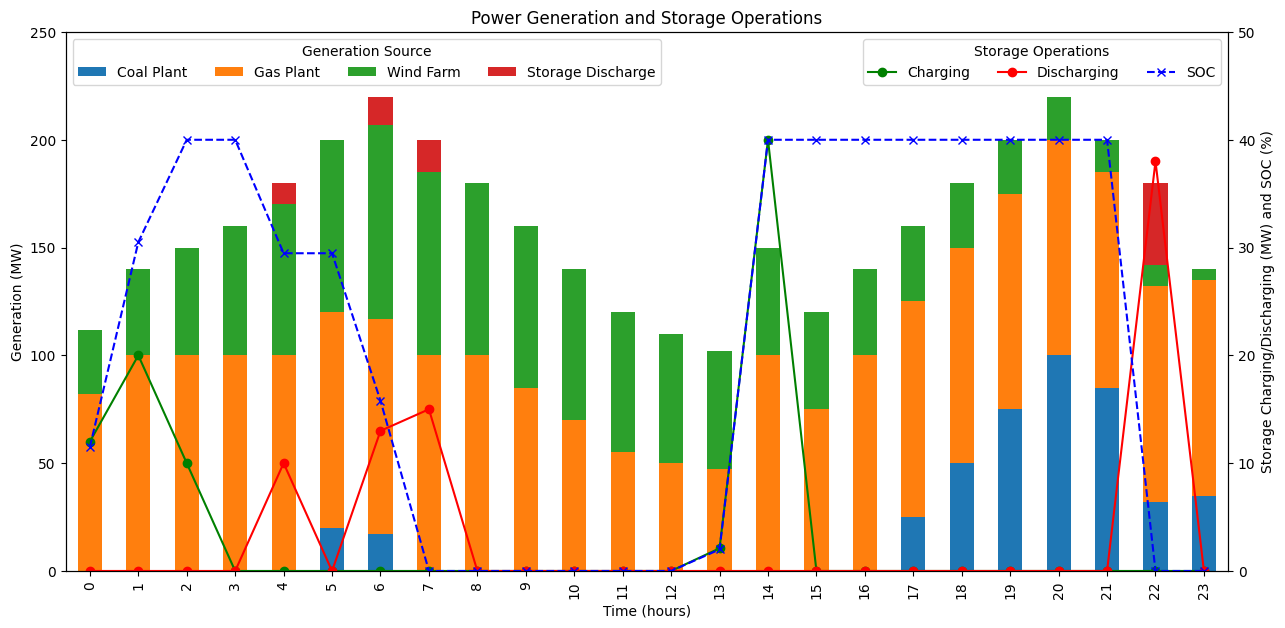

In [18]:
# Step 01: Compare total system costs
print(f"Old Fossil System Cost (OPEX only): "
      f"{network_old.objective:.2f}")
print(f"New Renewable System Cost (OPEX + CAPEX): "
      f"{network_new.objective:.2f}")

# Step 02: Calculate OPEX-only for the renewable system
renewable_opex = (network_new.generators_t.p * network_new.generators.marginal_cost).sum().sum()

print(f"New Renewable System OPEX only: "
      f"{renewable_opex:.2f}")


import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Organizing Data for Visualization
hours = range(24)
generation = network_new.generators_t.p
storage_charging = network_new.storage_units_t.p_store["Battery Storage"]
storage_discharging = network_new.storage_units_t.p_dispatch["Battery Storage"]
storage_soc = network_new.storage_units_t.state_of_charge["Battery Storage"]

# Convert to DataFrame for easy plotting
df_generation = pd.DataFrame(generation, index=hours)
df_storage = pd.DataFrame({
    'Charging': storage_charging,
    'Discharging': storage_discharging,
    'SOC': storage_soc
}, index=hours)

df_generation['Storage Discharge'] = df_storage['Discharging']

# Step 2: Designing the Visualization
fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot generation
df_generation.plot(ax=ax1, kind='bar', stacked=True)
ax1.set_title("Power Generation and Storage Operations")
ax1.set_xlabel("Time (hours)")
ax1.set_ylabel("Generation (MW)")
ax1.legend(title="Generation Source", loc='upper left', ncols=4)
ax1.set_ylim(0, 250)

# Plot storage parameters (second y-axis)
ax2 = ax1.twinx()

df_storage[['Charging', 'Discharging']].plot(
    ax=ax2, kind='line', marker='o', color=['green', 'red']
)

df_storage['SOC'].plot(
    ax=ax2, kind='line', marker='x', color='blue', linestyle='--'
)

ax2.set_ylabel("Storage Charging/Discharging (MW) and SOC (%)")
ax2.legend(title="Storage Operations", loc='upper right', ncols=3)
ax2.set_ylim(0, 50)

plt.show()

Σύνοψη Λειτουργίας Συστημάτων Παραγωγής και Αποθήκευσης

Το γράφημα απεικονίζει τη δυναμική αλληλεπίδραση μεταξύ των πηγών παραγωγής και της μονάδας αποθήκευσης σε ένα 24ωρο ( snapshots 0-23).
1. Δομή Γραφήματος
- **Αριστερός Άξονας (Y1)**: Παραγωγή ενέργειας σε MW (0-250).
- **Δεξιός Άξονας (Y2)**: Λειτουργία αποθήκευσης και επίπεδο φόρτισης (SOC) σε ποσοστό (0-50).
- **Μπάρες**: Σωρευτική απεικόνιση παραγωγής από τη μονάδα Άνθρακα (Coal), Φυσικού Αερίου (Gas) και το Αιολικό Πάρκο (Wind).
- **Γραμμές**: Φόρτιση (πράσινη), Εκφόρτιση (κόκκινη) και Επίπεδο Ενέργειας/SOC (μπλε διακεκομμένη).

2. Κύριες Παρατηρήσεις Παραγωγής
- Μονάδα Άνθρακα: Η παραγωγή της κορυφώνεται κατά τις βραδινές ώρες (19:00-22:00), φτάνοντας περίπου τα 100 MW.
- Μονάδα Αερίου: Διατηρεί σταθερή παρουσία όλη την ημέρα, με αυξημένη συνεισφορά το βράδυ για την κάλυψη της αιχμής του φορτίου.
- Αιολικό Πάρκο: Παρουσιάζει μεταβλητότητα, με μέγιστη απόδοση νωρίς το πρωί και αργά το βράδυ.

3. Λειτουργία Αποθήκευσης (Μπαταρία)
- Φόρτιση (Charging): Πραγματοποιείται κυρίως το μεσημέρι (11:00-16:00), εκμεταλλευόμενη προφανώς την περίσσεια ενέργειας ή το χαμηλότερο κόστος εκείνης της περιόδου.
- Εκφόρτιση (Discharging): Η μπαταρία δίνει ενέργεια στο δίκτυο (κόκκινες μπάρες) κυρίως το πρωί (05:00-07:00) και αργά το βράδυ (22:00-23:00).
- Επίπεδο Φόρτισης (SOC): Ξεκινά σε υψηλά επίπεδα, υποχωρεί μέχρι τις 07:00 λόγω εκφόρτισης, ανακάμπτει σταδιακά φτάνοντας στο μέγιστο γύρω στις 17:00 και μειώνεται ξανά στο τέλος της ημέρας.

---